# *Project Justus C. Sander*

#### Date set name: [Club Football Match Data (2000 - 2025) ⚽](https://www.kaggle.com/code/mahmoudredagamail/club-football-match-data-2000-2025)
#### Owner: Mahmoud Gamil

## 1. Preprocessing

### 1.1 Importing and viewing the dataset

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.io as pio

pio.templates.default = 'plotly_white'

In [2]:
file_path="../data/project/Matches.csv"

matches = pd.read_csv(file_path, dtype={'MatchTime': 'str'})

In [3]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

In [4]:
matches.head()

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Remove Columns not used for the project

In [5]:
# Remove Betting columns
betting_data = ['OddHome', 'OddDraw', 'OddAway', 'MaxHome', 'MaxDraw', 'MaxAway', 
              'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 'HandiSize', 'HandiHome', 'HandiAway', 'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB']
matches.drop(columns=betting_data, inplace=True)

In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 29 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

### 1.3 Remove Leagues when league does not start in Summer

### 1.4 Datetime format

In [7]:
# Combine MatchDate and MatchTime
matches['MatchTime'] = matches['MatchTime'].fillna('00:00:00')

In [8]:
matches['MatchDateTime'] = pd.to_datetime(matches['MatchDate'] + ' ' + matches['MatchTime'])

In [9]:
cols = ['MatchDateTime'] + [col for col in matches.columns if col != 'MatchDateTime']
matches = matches[cols]

In [10]:
matches.head() #check if MatchDateTime is the first column & MatchDate + MatchTime were deleted

,MatchDateTime,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,...,HomeTarget,AwayTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed
0,2000-07-28,F1,2000-07-28,00:00:00,Marseille,Troyes,1686.34,1586.57,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-07-28,F1,2000-07-28,00:00:00,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-07-28,F2,2000-07-28,00:00:00,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-07-29,F1,2000-07-29,00:00:00,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-07-29,F1,2000-07-29,00:00:00,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
matches.info() #Check if datetype changed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 30 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   MatchDateTime  230557 non-null  datetime64[ns]
 1   Division       230557 non-null  object        
 2   MatchDate      230557 non-null  object        
 3   MatchTime      230557 non-null  object        
 4   HomeTeam       230557 non-null  object        
 5   AwayTeam       230557 non-null  object        
 6   HomeElo        141597 non-null  float64       
 7   AwayElo        141528 non-null  float64       
 8   Form3Home      229057 non-null  float64       
 9   Form5Home      229057 non-null  float64       
 10  Form3Away      229057 non-null  float64       
 11  Form5Away      229057 non-null  float64       
 12  FTHome         230554 non-null  float64       
 13  FTAway         230554 non-null  float64       
 14  FTResult       230554 non-null  object        
 15  

### 1.5 Change league names

In [12]:
league_names = {
    'E0': 'England Premier League',
    'E1': 'England Championship',
    'E2': 'England League One',
    'E3': 'England League Two',
    'EC': 'England Conference',
    'SC0': 'Scotland Premiership',
    'SC1': 'Scotland Championship',
    'SC2': 'Scotland League One',
    'SC3': 'Scotland League Two',
    'D1': 'Germany Bundesliga',
    'D2': 'Germany 2. Bundesliga',
    'I1': 'Italy Serie A',
    'I2': 'Italy Serie B',
    'SP1': 'Spain La Liga',
    'SP2': 'Spain Segunda Division',
    'F1': 'France Ligue 1',
    'F2': 'France Ligue 2',
    'N1': 'Netherlands Eredivisie',
    'B1': 'Belgium First Division A',
    'P1': 'Portugal Primeira Liga',
    'T1': 'Turkey Super Lig',
    'G1': 'Greece Super League',
    'ARG': 'Argentina Primera Division',
    'USA': 'USA MLS',
    'BRA': 'Brazil Serie A',
    'JAP': 'Japan J League',
    'MEX': 'Mexico Liga MX',
    'ROM': 'Romania Liga I',
    'POL': 'Poland Ekstraklasa',
    'SWE': 'Sweden Allsvenskan',
    'NOR': 'Norway Eliteserien',
    'RUS': 'Russia Premier League',
    'DEN': 'Denmark Superliga',
    'CHN': 'China Super League',
    'IRL': 'Ireland Premier Division',
    'FIN': 'Finland Veikkausliiga',
    'AUT': 'Austria Bundesliga',
    'SUI': 'Switzerland Super League'
}

matches['Division'] = matches['Division'].replace(league_names)

In [13]:
calendar_year_leagues = [
    'USA MLS',
    'Brazil Serie A',
    'Japan J League',
    'China Super League',
    'Argentina Primera Division',
    'Sweden Allsvenskan',
    'Norway Eliteserien',
    'Finland Veikkausliiga',
    'Ireland Premier Division'
]
matches = matches[~matches['Division'].isin(calendar_year_leagues)]

### 1.6 Add additional columns

In [14]:
def get_season(date):
    year = date.year
    if date.month >= 8:  # August or later
        return f"{year}/{str(year+1)[2:]}"
    else:  # Januar until Juli
        return f"{year-1}/{str(year)[2:]}"

matches['Season'] = matches['MatchDateTime'].apply(get_season)

print(matches[['MatchDateTime', 'Season']].sample(10))

#Games before August 2000 are matched with the wrong season
matches.loc[matches['Season'] == '1999/00', 'Season'] = '2000/01'
print(matches['Season'].unique())

matches['MatchHour'] = matches['MatchDateTime'].dt.hour

       MatchDateTime   Season
31858     2006-02-03  2005/06
157650    2019-02-09  2018/19
88393     2013-05-04  2012/13
109822    2015-03-07  2014/15
84799     2013-02-03  2012/13
161717    2019-05-19  2018/19
94962     2013-12-14  2013/14
125274    2016-05-25  2015/16
71756     2011-10-29  2011/12
60673     2010-03-14  2009/10
['2000/01' '2001/02' '2002/03' '2003/04' '2004/05' '2005/06' '2006/07'
 '2007/08' '2008/09' '2009/10' '2010/11' '2011/12' '2012/13' '2013/14'
 '2014/15' '2015/16' '2016/17' '2017/18' '2018/19' '2019/20' '2020/21'
 '2021/22' '2022/23' '2023/24' '2024/25']


In [15]:
matches['TotalGoals'] = matches['FTHome'] + matches['FTAway'] #include the total goal number per game
matches['TotalShotsOnTarget'] = matches['HomeTarget'] + matches['AwayTarget']
matches['TotalYellow'] = matches['HomeYellow'] + matches['AwayYellow']
matches['TotalRed'] = matches['HomeRed'] + matches['AwayRed']

## 2. Tasks and Questions

### Theme 1: Goals & Scoring

1. How does the average number of goals per match differ across leagues?
2. How has the average number of goals per season changed over the years (2000–2025)? top 5 leagues
3. How has the average number of shots on target evolved over time — is there a trend toward more "offensive" football?
4. Does kickoff time affect the number of goals scored?

### Theme 2: Home Advantage

5. Is there a home advantage, and is it stronger in some leagues than others?
6. Has home advantage changed over the 25 years?
7. Which teams show the most consistent home advantage over time (top 5 clubs by home win %)?
8. Is there a "COVID effect" (matches without spectators) visible in home advantage?

### Theme 3: Team Strength & Discipline

9. Does the Elo difference correlate with win probability, and has this correlation changed over the years?
10. How has the average number of yellow/red cards evolved per year

### Bonus
11. How is the over/under 2.5 goals ratio distributed by league and year? 

### 2.1 Question 1
*How does the average number of goals per match differ across leagues (all or top 5)?*

In [16]:
df_q1 = matches[['Division', 'TotalGoals']].dropna()
df_q1 = df_q1.groupby('Division')['TotalGoals'].mean().reset_index()
df_q1.columns = ['Division', 'AvgGoals']

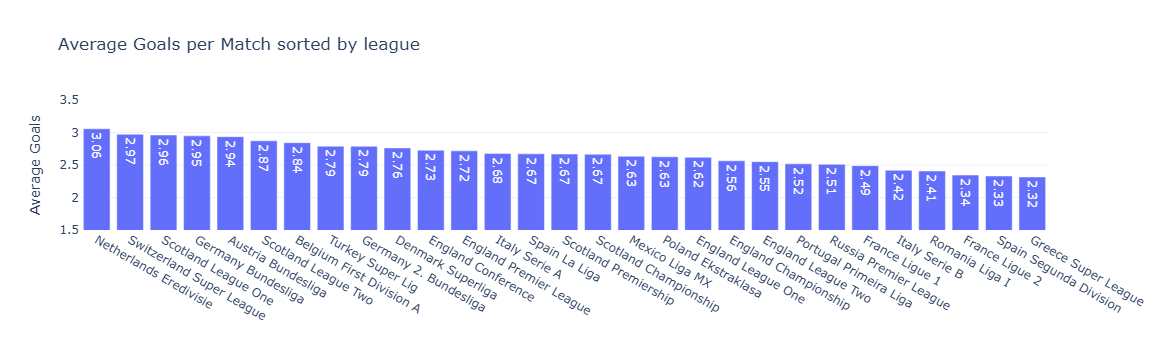

In [17]:
fig_q1a = px.bar(
   data_frame=df_q1,
    x='Division',
    y='AvgGoals',
    title="Average Goals per Match sorted by league",
    labels={"Division": " ", "AvgGoals": "Average Goals"},
    text_auto='.2f'  # zeigt Werte direkt auf den Balken an
)

fig_q1a.update_xaxes(categoryorder='total descending')
fig_q1a.update_yaxes(range=[1.5, 3.5])


fig_q1a.show()

For the top 5 leagues:

In [18]:
top5_leagues = [
    'Germany Bundesliga', 
    'France Ligue 1', 
    'England Premier League', 
    'Spain La Liga', 
    'Italy Serie A'
]
df_q1 = matches[['Division', 'TotalGoals']].dropna()
df_q1 = df_q1.loc[matches['Division'].isin(top5_leagues), :]
df_q1 = df_q1.groupby('Division')['TotalGoals'].mean().reset_index()
df_q1.columns = ['Division', 'AvgGoals']
df_q1.head()

,Division,AvgGoals
0,England Premier League,2.717535
1,France Ligue 1,2.489950
2,Germany Bundesliga,2.948418
3,Italy Serie A,2.678540
4,Spain La Liga,2.672624


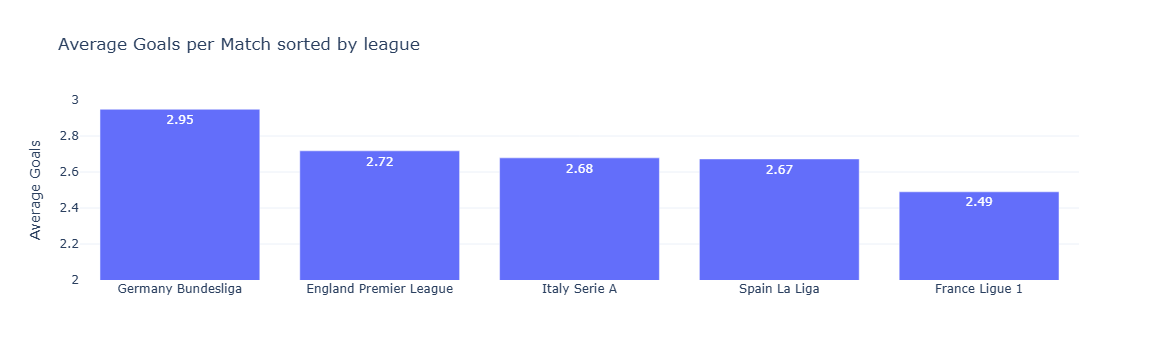

In [19]:
fig_q1b = px.bar(
   data_frame=df_q1,
    x='Division',
    y='AvgGoals',
    title="Average Goals per Match sorted by league",
    labels={"Division": " ", "AvgGoals": "Average Goals"},
    text_auto='.2f'  # zeigt Werte direkt auf den Balken an
)

fig_q1b.update_xaxes(categoryorder='total descending')
fig_q1b.update_yaxes(range=[2, 3])


fig_q1b.show()

Most goals are scored in the Bundesliga. England, Italy and Spain are similar and France has the lowest number of average goals.

### 2.2 Question 2
*How has the average number of goals per season changed over the years (2000–2025)? top 5 leagues*

In [20]:
df_q2 = matches[['Division', 'TotalGoals','Season']].dropna()
df_q2 = df_q2.loc[df_q2['Division'].isin(top5_leagues), :]
df_q2 = df_q2.groupby(['Division','Season'])['TotalGoals'].mean().reset_index()
df_q2.columns = ['Division', 'Season', 'Average Goals']
df_q2.head()

,Division,Season,Average Goals
0,England Premier League,2000/01,2.610526
1,England Premier League,2001/02,2.634211
2,England Premier League,2002/03,2.631579
3,England Premier League,2003/04,2.635821
4,England Premier League,2004/05,2.540299


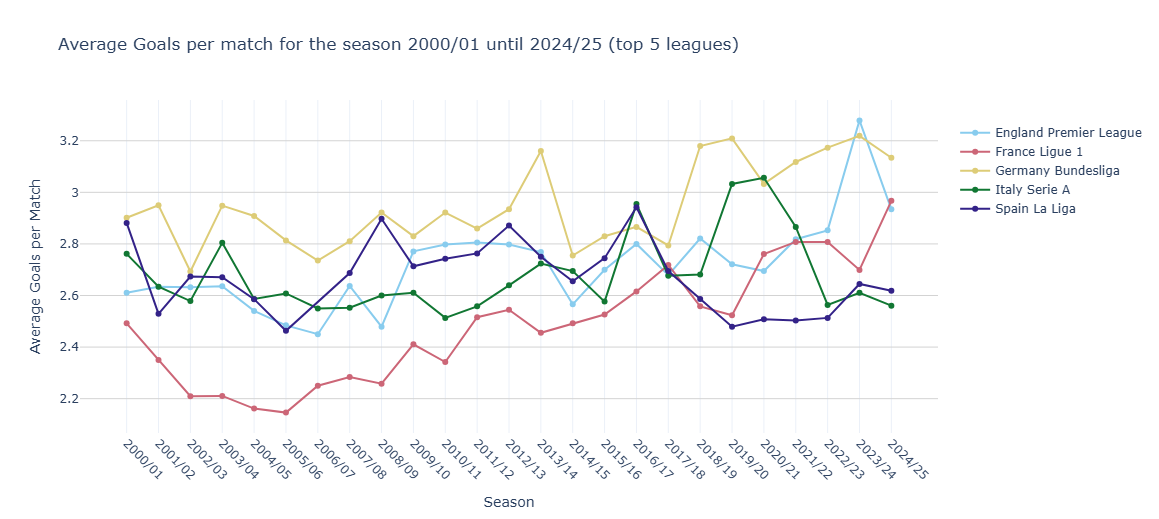

In [21]:
fig_q2 = px.line(
    data_frame=df_q2,
    x="Season",
    y="Average Goals",
    hover_name='Division',
    color= 'Division',
    color_discrete_sequence=px.colors.qualitative.Safe,
    markers=True, # to turn markers on - default is off
    title="Average Goals per match for the season 2000/01 until 2024/25 (top 5 leagues)",
    height=500
    )


fig_q2.update_layout(
    width=1200,
    legend_title_text=' '
    )

fig_q2.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q2['Season'].unique())
    )

fig_q2.update_yaxes(
    title="Average Goals per Match",
    gridcolor='lightgrey'
    )

fig_q2.show()

No clear trend, except for France. It looks like the number of average goals per match increased over the years.

### 2.3 Question 3
*How has the average number of shots on target evolved over time — is there a trend toward more "offensive" football?*

In [22]:
df_q3 = matches[['Division', 'Season', 'TotalShotsOnTarget']].dropna()
df_q3 = df_q3.loc[df_q3['Division'].isin(top5_leagues), :]
df_q3 = df_q3.groupby(['Division', 'Season'])['TotalShotsOnTarget'].mean().reset_index()
df_q3.columns = ['Division', 'Season', 'Average Shots on Target']
df_q3.head()

,Division,Season,Average Shots on Target
0,England Premier League,2000/01,10.694737
1,England Premier League,2001/02,10.150000
2,England Premier League,2002/03,11.871053
3,England Premier League,2003/04,12.510448
4,England Premier League,2004/05,11.838806


In [23]:
print(df_q3.groupby('Division')['Season'].min())
print(df_q3.groupby('Division')['Season'].nunique())

Division
England Premier League    2000/01
France Ligue 1            2004/05
Germany Bundesliga        2000/01
Italy Serie A             2005/06
Spain La Liga             2005/06
Name: Season, dtype: object
Division
England Premier League    25
France Ligue 1            21
Germany Bundesliga        21
Italy Serie A             20
Spain La Liga             19
Name: Season, dtype: int64


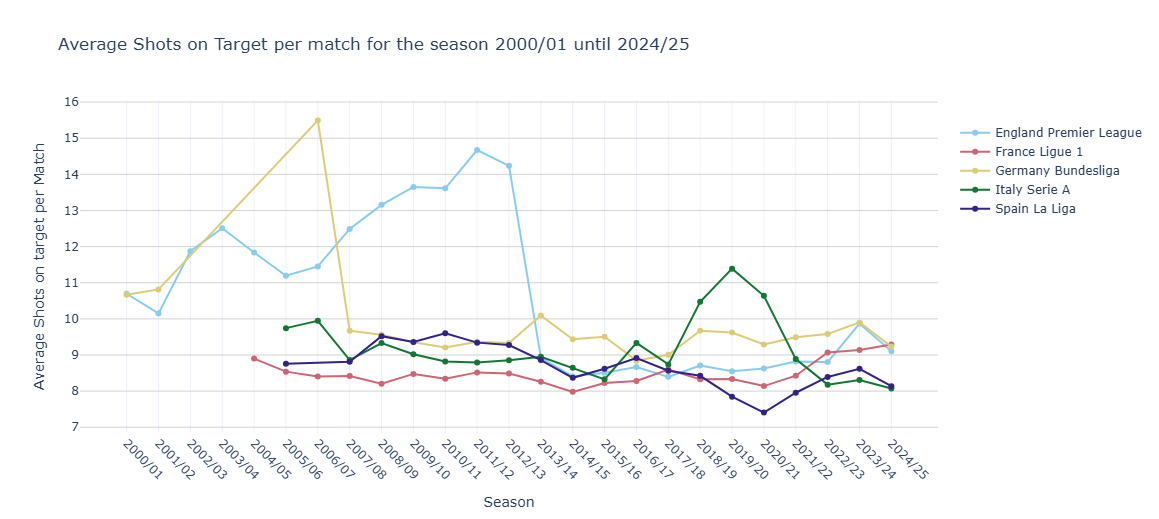

In [24]:
fig_q3 = px.line(
    data_frame=df_q3,
    x="Season",
    y="Average Shots on Target",
    hover_name='Division',
    color= 'Division',
    color_discrete_sequence=px.colors.qualitative.Safe,
    markers=True, # to turn markers on - default is off
    title="Average Shots on Target per match for the season 2000/01 until 2024/25",
    height=500
    )


fig_q3.update_layout(
    width=1200,
    legend_title_text=' '
    )

fig_q3.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q2['Season'].unique())
    )

fig_q3.update_yaxes(
    title="Average Shots on target per Match",
    gridcolor='lightgrey'
    )

fig_q3.show()

No trend towards more offensiv football. Until 2013 the numer of shots was way higher in england then in the last couple of years. For the Bundesliga the season 2006/07 had way more shots than usually.

### 2.4 Question 4
*Does kickoff time affect the number of goals scored?*

In [25]:
df_q4 = matches.loc[matches['Division'].isin(top5_leagues), :]
df_q4 = df_q4[['Division', 'MatchHour', 'TotalGoals']].dropna()
df_q4 = df_q4[df_q4['MatchHour'] != 0]
df_q4.columns = ['Division', 'Match Time (by hour)', 'Total Goals']
#print(df_q5['MatchHour'].value_counts().sort_index())
df_q4.head()

,Division,Match Time (by hour),Total Goals
162888,France Ligue 1,19,3.0
162891,England Premier League,20,5.0
162895,England Premier League,12,5.0
162949,England Premier League,15,2.0
162950,England Premier League,15,3.0


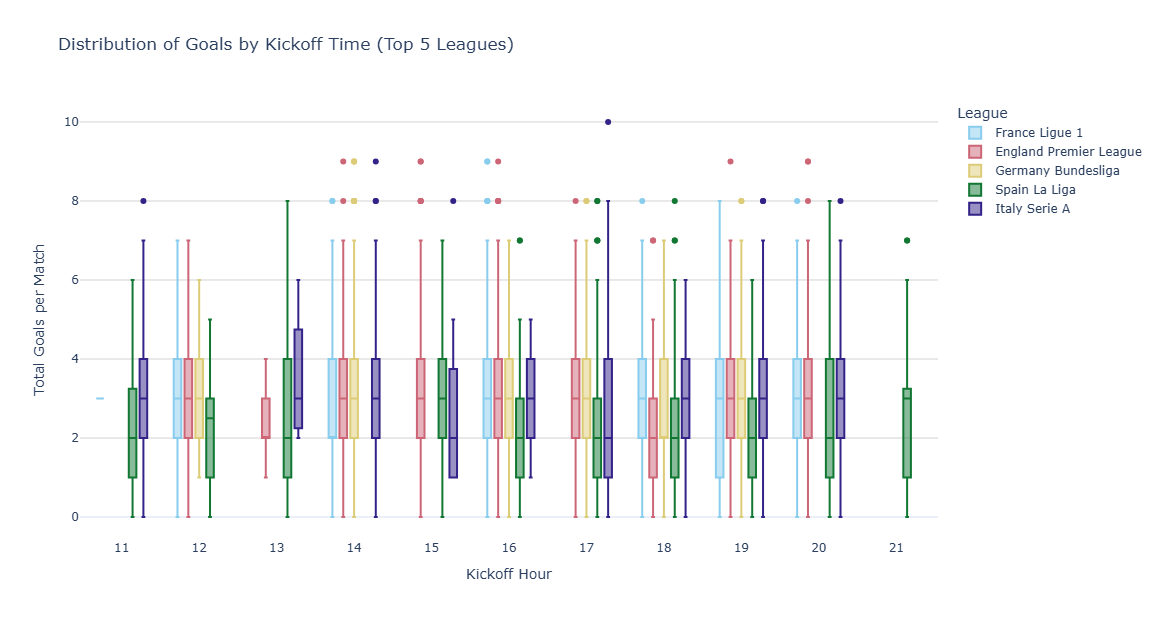

In [26]:
fig_q4a = px.box(
    data_frame=df_q4,
    x='Match Time (by hour)',
    y='Total Goals',
    hover_name='Division',
    color='Division',
    title="Distribution of Goals by Kickoff Time (Top 5 Leagues)",
    labels={"Match Time (by hour)": "Kickoff Hour", "Total Goals": "Total Goals per Match", "Division": "League"},
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_q4a.update_layout(
    width=1200,
    height=600,
    legend_title_text='League'
)

fig_q4a.update_xaxes(
    title="Kickoff Hour",
    dtick=1
)

fig_q4a.update_yaxes(
    title="Total Goals per Match",
    gridcolor='lightgrey'
)

fig_q4a.show()

In [27]:
df_q4 = matches.loc[matches['Division'] == 'Germany Bundesliga', :]
df_q4 = df_q4[['Division', 'MatchHour', 'TotalGoals']].dropna()
df_q4 = df_q4[df_q4['MatchHour'] != 0]
df_q4.columns = ['Division', 'Match Time (by hour)', 'Total Goals']
#print(df_q5['MatchHour'].value_counts().sort_index())
df_q4.head()

,Division,Match Time (by hour),Total Goals
163099,Germany Bundesliga,19,4.0
163129,Germany Bundesliga,14,6.0
163130,Germany Bundesliga,14,3.0
163131,Germany Bundesliga,14,5.0
163132,Germany Bundesliga,14,4.0


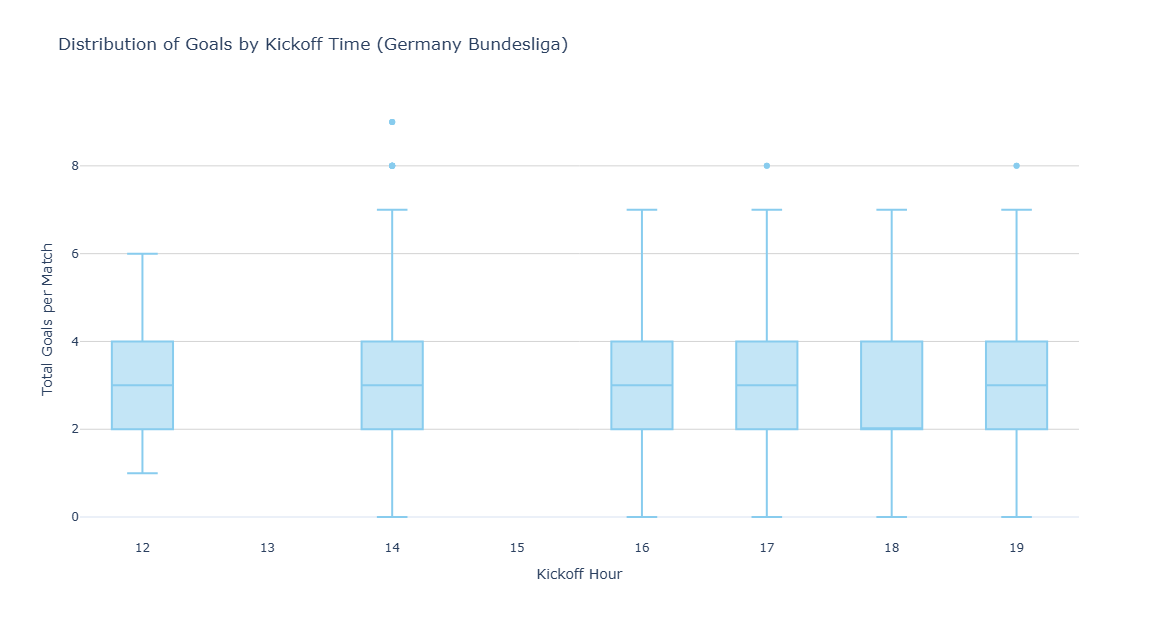

In [28]:
fig_q4b = px.box(
    data_frame=df_q4,
    x='Match Time (by hour)',
    y='Total Goals',
    title="Distribution of Goals by Kickoff Time (Germany Bundesliga)",
    labels={"Match Time (by hour)": "Kickoff Hour", "Total Goals": "Total Goals per Match", "Division": "League"},
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_q4b.update_layout(
    width=1200,
    height=600,
    legend_title_text='League'
)

fig_q4b.update_xaxes(
    title="Kickoff Hour",
    dtick=1
)

fig_q4b.update_yaxes(
    title="Total Goals per Match",
    gridcolor='lightgrey'
)

fig_q4b.show()

No trend visible that the number of goals is different for different Kickoff hours.

### 2.5 Question 5
*Is there a home advantage, and is it stronger in some leagues than others?*

In [29]:
df_q5 = matches[matches['Division'].isin(top5_leagues)][['Division', 'FTResult']].dropna()
df_q5 = df_q5.groupby(['Division', 'FTResult']).size().reset_index(name='Count')
# in percent
df_q5['Percentage'] = df_q5.groupby('Division')['Count'].transform(lambda x: x / x.sum() * 100)

df_q5.head()

,Division,FTResult,Count,Percentage
0,England Premier League,A,2782,29.564293
1,England Premier League,D,2318,24.633369
2,England Premier League,H,4310,45.802338
3,France Ligue 1,A,2378,27.158520
4,France Ligue 1,D,2435,27.809502


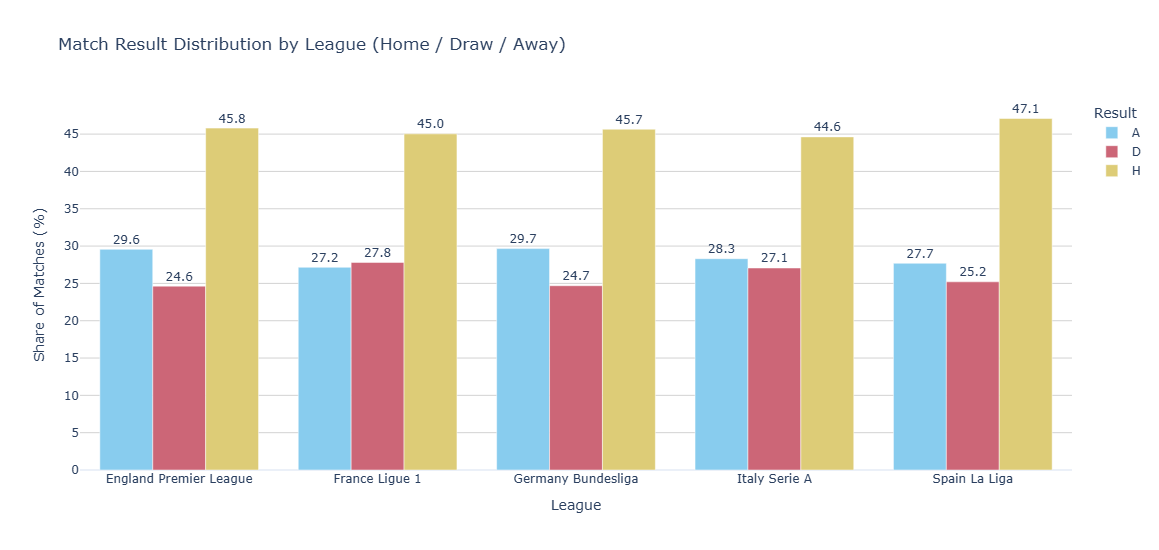

In [30]:
import plotly.express as px

fig_q5 = px.bar(
    data_frame=df_q5,
    x='Division',
    y='Percentage',
    hover_name='Division',
    color='FTResult',
    barmode='group',
    title="Match Result Distribution by League (Home / Draw / Away)",
    labels={"Division": "League", "Percentage": "Share of Matches (%)", "FTResult": "Result"},
    color_discrete_sequence=px.colors.qualitative.Safe,
    text_auto='.1f'
)

fig_q5.update_layout(
    width=1000,
    height=550,
    legend_title_text='Result'
)

fig_q5.update_xaxes(
    title="League"
)

fig_q5.update_yaxes(
    title="Share of Matches (%)",
    gridcolor='lightgrey'
)

fig_q5.update_traces(
    textposition='outside'
)

fig_q5.show()

Home advantage is similar in the top 5 leagues.

### 2.6 Question 6
*Has home advantage changed over the 25 years?*

In [31]:
df_q6 = matches.loc[matches['Division'].isin(top5_leagues), :]
df_q6 = df_q6[['Season',  'FTResult']].dropna()
df_q6 = df_q6.groupby(['Season', 'FTResult']).size().reset_index(name='Count')
# in percent
df_q6['Percentage'] = df_q6.groupby(['Season'])['Count'].transform(lambda x: x / x.sum() * 100)
df_q6 = df_q6.loc[df_q6['FTResult'] == 'H', :]
result_names = {'H': 'Home Win'}
df_q6['FTResult'] = df_q6['FTResult'].map(result_names)

df_q6.head()

,Season,FTResult,Count,Percentage
2,2000/01,Home Win,845,49.852507
5,2001/02,Home Win,801,48.223961
8,2002/03,Home Win,728,47.058824
11,2003/04,Home Win,606,45.701357
14,2004/05,Home Win,745,46.591620


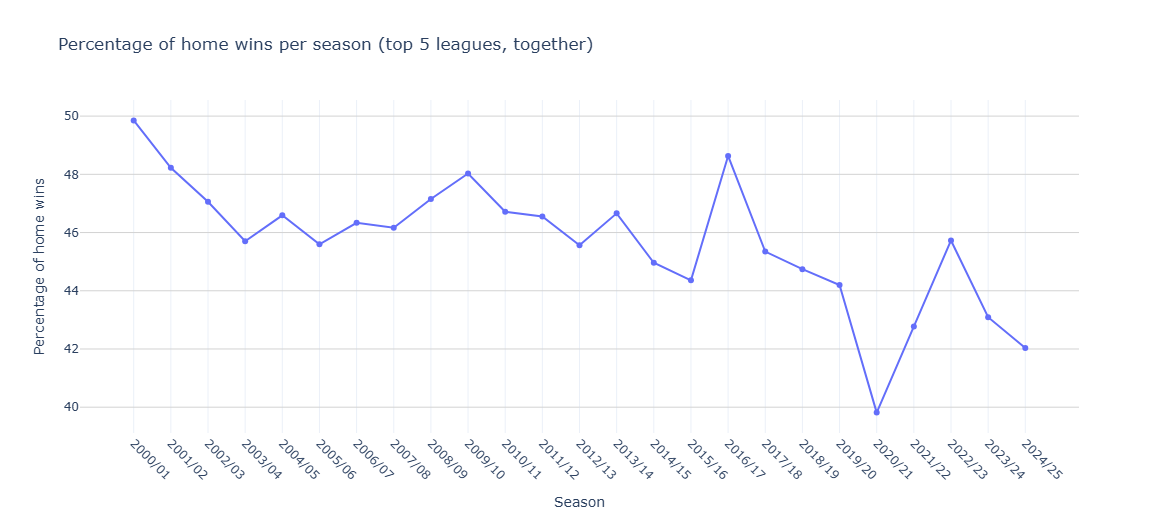

In [32]:
fig_q6a = px.line(
    data_frame=df_q6,
    x="Season",
    y="Percentage",
    markers=True, # to turn markers on - default is off
    title="Percentage of home wins per season (top 5 leagues, together)",
    height=500
    )


fig_q6a.update_layout(
    width=1200,
    legend_title_text=' '
    )

fig_q6a.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q2['Season'].unique())
    )

fig_q6a.update_yaxes(
    title="Percentage of home wins",
    gridcolor='lightgrey'
    )

fig_q6a.show()

The home advantage decreased over the time, if you look at all 5 top leagues together.

In [33]:
df_q6 = matches.loc[matches['Division'].isin(top5_leagues), :]
df_q6 = df_q6[['Division', 'Season',  'FTResult']].dropna()
df_q6 = df_q6.groupby(['Division', 'Season', 'FTResult']).size().reset_index(name='Count')
# in percent
df_q6['Percentage'] = df_q6.groupby(['Division', 'Season'])['Count'].transform(lambda x: x / x.sum() * 100)
df_q6 = df_q6.loc[df_q6['FTResult'] == 'H', :]
result_names = {'H': 'Home Win'}
df_q6['FTResult'] = df_q6['FTResult'].map(result_names)

df_q6.head()

,Division,Season,FTResult,Count,Percentage
2,England Premier League,2000/01,Home Win,184,48.421053
5,England Premier League,2001/02,Home Win,165,43.421053
8,England Premier League,2002/03,Home Win,187,49.210526
11,England Premier League,2003/04,Home Win,150,44.776119
14,England Premier League,2004/05,Home Win,150,44.776119


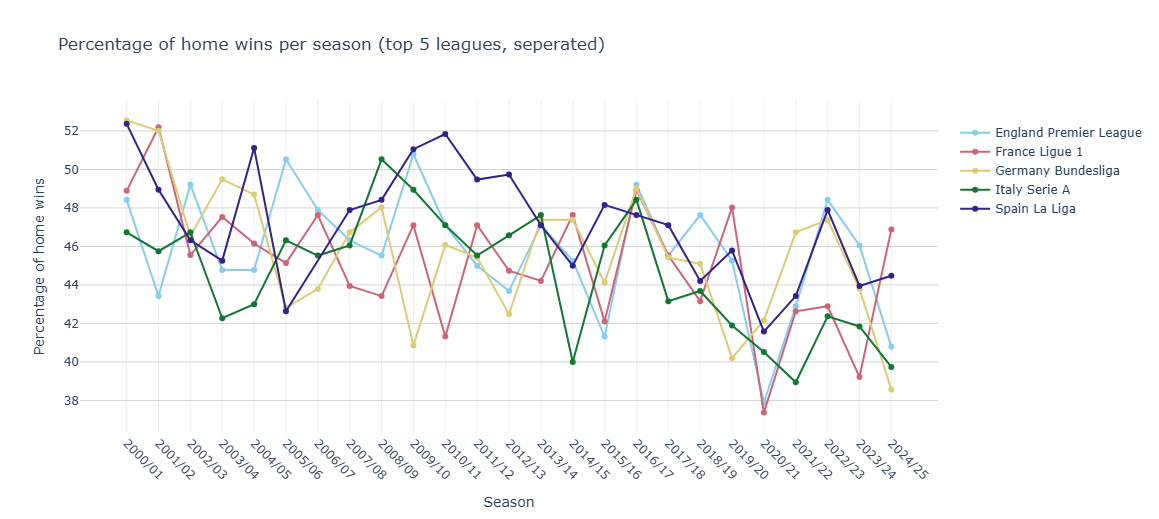

In [34]:
fig_q6b = px.line(
    data_frame=df_q6,
    x="Season",
    y="Percentage",
    hover_name='Division',
    color= 'Division',
    color_discrete_sequence=px.colors.qualitative.Safe,
    markers=True, # to turn markers on - default is off
    title="Percentage of home wins per season (top 5 leagues, seperated)",
    height=500
    )


fig_q6b.update_layout(
    width=1200,
    legend_title_text=' '
    )

fig_q6b.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q2['Season'].unique())
    )

fig_q6b.update_yaxes(
    title="Percentage of home wins",
    gridcolor='lightgrey'
    )

fig_q6b.show()

### 2.7 Question 7
*Which teams show the most consistent home advantage over time (top 5 clubs by home win %, in top 5 leagues)?*

In [35]:
df_q7 = matches.loc[matches['Division'].isin(top5_leagues), :]
df_q7 = df_q7[['HomeTeam',  'FTResult']].dropna()
df_q7 = df_q7.groupby(['HomeTeam', 'FTResult']).size().reset_index(name='Count')
# in percent
df_q7['Percentage'] = df_q7.groupby(['HomeTeam'])['Count'].transform(lambda x: x / x.sum() * 100)
df_q7 = df_q7.loc[df_q7['FTResult'] == 'H', :]
result_names = {'H': 'Home Win'}
df_q7['FTResult'] = df_q7['FTResult'].map(result_names)

top5_teams = df_q7.sort_values('Percentage', ascending=False).head(5)['HomeTeam'].tolist()

In [36]:
df_q7 = matches[['Season', 'HomeTeam',  'FTResult']].dropna()
df_q7 = df_q7[df_q7['HomeTeam'].isin(top5_teams)]
df_q7 = df_q7.groupby(['Season', 'HomeTeam', 'FTResult']).size().reset_index(name='Count')
# in percent
df_q7['Percentage'] = df_q7.groupby(['Season', 'HomeTeam'])['Count'].transform(lambda x: x / x.sum() * 100)
df_q7 = df_q7.loc[df_q7['FTResult'] == 'H', :]
result_names = {'H': 'Home Win'}
df_q7['FTResult'] = df_q7['FTResult'].map(result_names)

df_q7.head()

,Season,HomeTeam,FTResult,Count,Percentage
2,2000/01,Barcelona,Home Win,12,63.157895
5,2000/01,Bayern Munich,Home Win,12,70.588235
8,2000/01,Juventus,Home Win,11,64.705882
11,2000/01,Man United,Home Win,15,78.947368
14,2000/01,Real Madrid,Home Win,15,78.947368


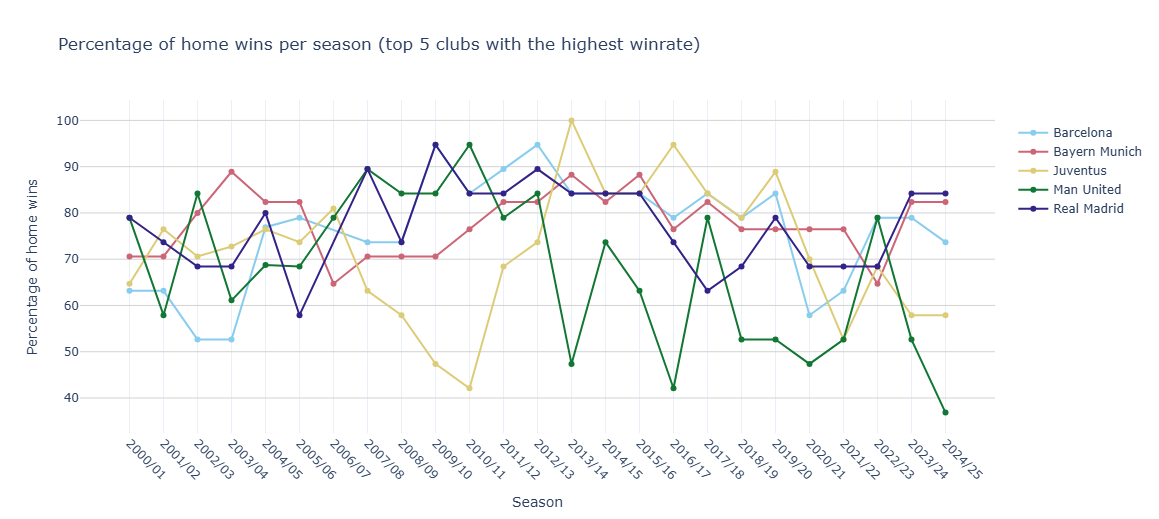

In [37]:
fig_q7 = px.line(
    data_frame=df_q7,
    x="Season",
    y="Percentage",
    color= 'HomeTeam',
    hover_name='HomeTeam',
    color_discrete_sequence=px.colors.qualitative.Safe,
    markers=True, # to turn markers on - default is off
    title="Percentage of home wins per season (top 5 clubs with the highest winrate)",
    height=500
    )


fig_q7.update_layout(
    width=1200,
    legend_title_text=' '
    )

fig_q7.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q2['Season'].unique())
    )

fig_q7.update_yaxes(
    title="Percentage of home wins",
    gridcolor='lightgrey'
    )

fig_q7.show()

Bayern and Real Madrid have the most consistent winrates. In 2013/14 Juventus won all home games. Manchester United only had two seasons with a home winrate over 75%.

### 2.8 Question 8
*Is there a "COVID effect" (matches without spectators) visible in home advantage for Bundesliga Clubs?*

In [38]:
df_q8 = matches.loc[(matches['Division'] == 'Germany Bundesliga') & (matches['Season'] == '2019/20'), :]
df_q8 = df_q8[['MatchDateTime', 'HomeTeam', 'FTResult']].dropna()

covid_start = pd.Timestamp('2020-03-11')
df_q8['Period'] = df_q8['MatchDateTime'].apply(lambda x: 'Post-COVID (No Spectators)' if x >= covid_start else 'Pre-COVID (With Spectators)')
df_q8['IsHomeWin'] = (df_q8['FTResult'] == 'H').astype(int)

df_q8 = df_q8.groupby(['HomeTeam', 'Period'])['IsHomeWin'].mean().reset_index()
df_q8.columns = ['Team', 'Period', 'Home Win Rate']

df_q8.head()

,Team,Period,Home Win Rate
0,Augsburg,Post-COVID (No Spectators),0.000000
1,Augsburg,Pre-COVID (With Spectators),0.416667
2,Bayern Munich,Post-COVID (No Spectators),1.000000
3,Bayern Munich,Pre-COVID (With Spectators),0.692308
4,Dortmund,Post-COVID (No Spectators),0.400000


In [39]:
fig_q8 = px.bar(
    data_frame=df_q8,
    x='Team',
    y='Home Win Rate',
    color='Period',
    hover_name='Team',
    barmode='group',
    title="Home Win Rate by Bundesliga Club — Before vs. After COVID (No Spectators)",
    labels={"Team": "Club", "Home Win Rate": "Home Win Rate", "Period": "Period"},
    color_discrete_sequence=px.colors.qualitative.Safe
)

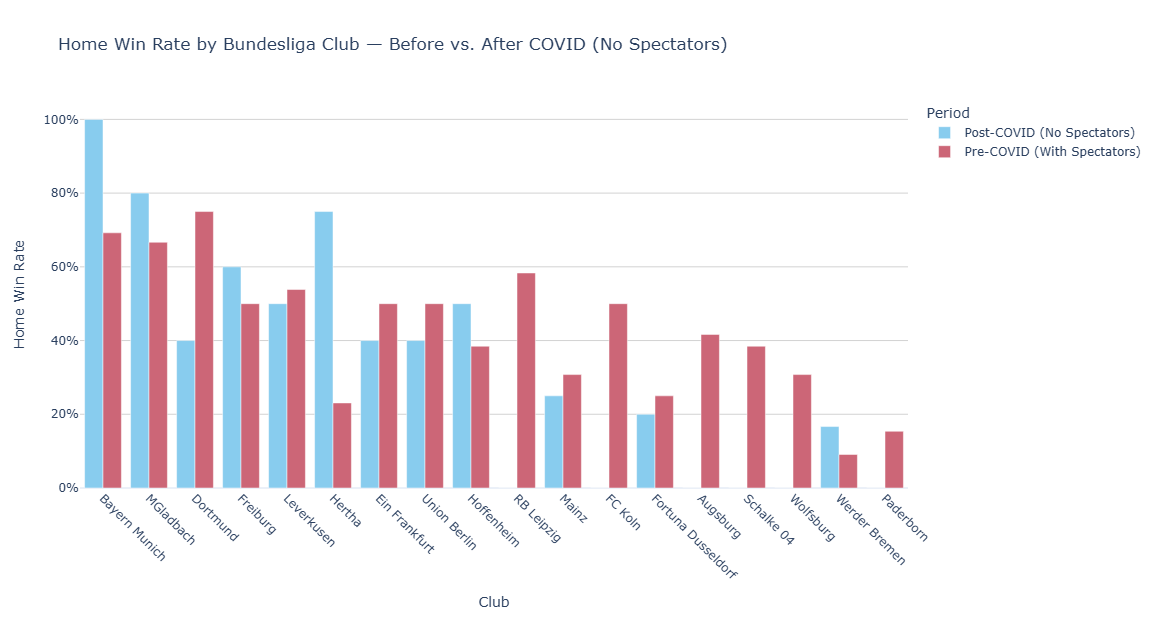

In [40]:
fig_q8.update_layout(
    width=1300,
    height=600,
    legend_title_text='Period'
)
fig_q8.update_xaxes(
    title="Club",
    tickangle=45,
    categoryorder='total descending'
)
fig_q8.update_yaxes(
    title="Home Win Rate",
    tickformat=".0%",
    gridcolor='lightgrey'
)

fig_q8.show()

In [41]:
df_q8b = df_q8.pivot(index='Team', columns='Period', values='Home Win Rate').reset_index()
df_q8b['Difference'] = df_q8b['Post-COVID (No Spectators)'] - df_q8b['Pre-COVID (With Spectators)']
df_q8b = df_q8b.sort_values('Difference', ascending=False)

df_q8b.head()

Period,Team,Post-COVID (No Spectators),Pre-COVID (With Spectators),Difference
7,Hertha,0.75,0.230769,0.519231
1,Bayern Munich,1.00,0.692308,0.307692
10,MGladbach,0.80,0.666667,0.133333
8,Hoffenheim,0.50,0.384615,0.115385
6,Freiburg,0.60,0.500000,0.100000


In [42]:
fig_q8b = px.bar(
    data_frame=df_q8b,
    x='Team',
    y='Difference',
    color='Difference',
    hover_name='Team',
    color_continuous_scale=['#D55E00', 'lightgrey', '#0072B2'],    color_continuous_midpoint=0,
    title="Change in Home Win Rate — Bundesliga Clubs (Post-COVID vs. Pre-COVID)",
    labels={"Team": "Club", "Difference": "Change in Home Win Rate"}
)

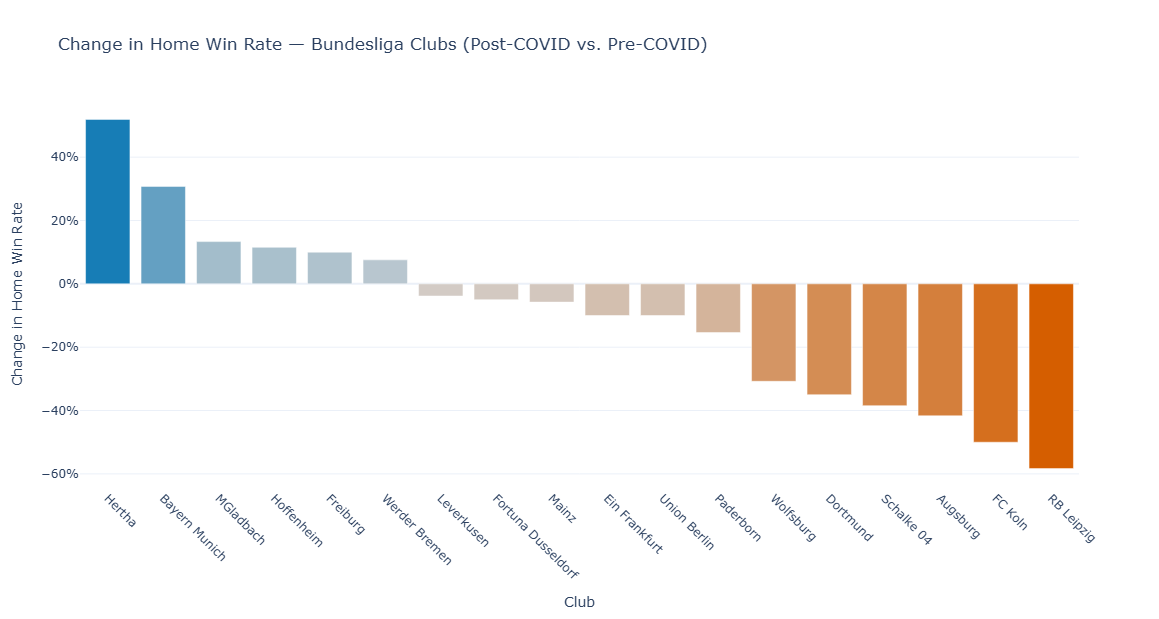

In [43]:
fig_q8b.update_layout(
    width=1300,
    height=600,
    coloraxis_showscale=False
)
fig_q8b.update_xaxes(
    title="Club",
    tickangle=45,
    categoryorder='total descending'
)
fig_q8b.update_yaxes(
    title="Change in Home Win Rate",
    tickformat=".0%",
)

fig_q8b.show()

The trend is different for the bundesliga clubs

### 2.9 Question 9
*Does the Elo difference correlate with win probability, and has this correlation changed over the years (top 5 leagues)?*

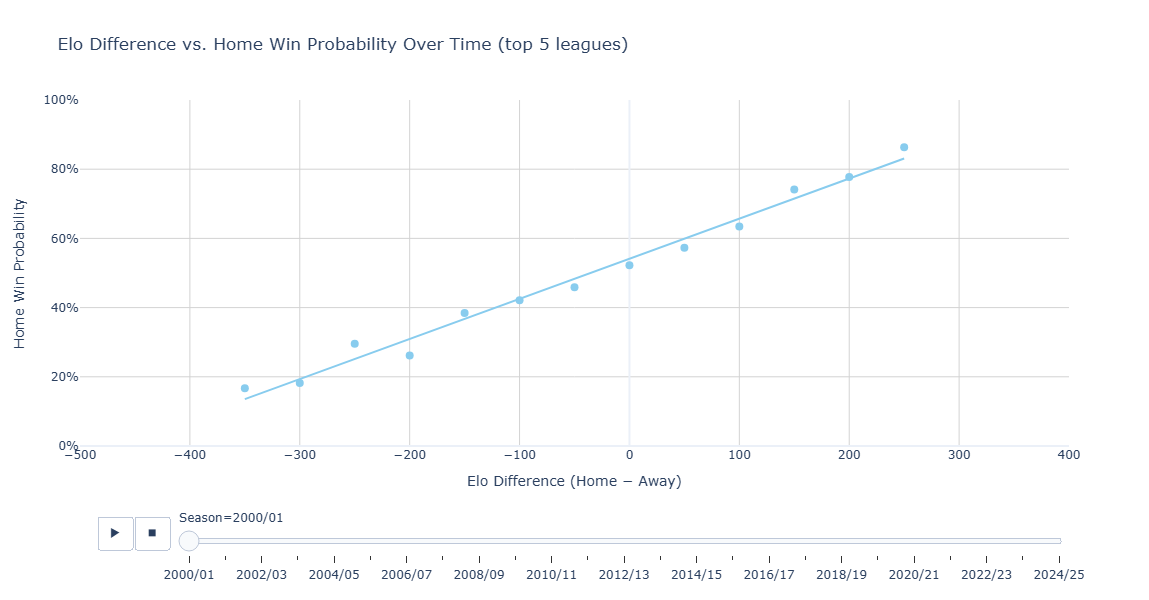

In [53]:
df_q9 = matches[matches['Division'].isin(top5_leagues)][['Season', 'HomeElo', 'AwayElo', 'FTResult']].dropna()
df_q9['EloDifference'] = df_q9['HomeElo'] - df_q9['AwayElo']
df_q9['HomeWin'] = (df_q9['FTResult'] == 'H').astype(int)

import numpy as np
# Elo difference in 50 bins
df_q9['EloBin'] = (df_q9['EloDifference'] // 50) * 50

# mean and count of games per bin
df_q9 = df_q9.groupby(['Season', 'EloBin'])['HomeWin'].agg(['mean', 'count']).reset_index()
df_q9.columns = ['Season', 'Elo Difference', 'Win Probability', 'Match Count']

# Bins with not enough games
df_q9 = df_q9[df_q9['Match Count'] >= 5]

df_q9.head()

fig_q9 = px.scatter(
    data_frame=df_q9,
    x='Elo Difference',
    y='Win Probability',
    animation_frame='Season',
    hover_name='Season',
    trendline='ols',
    title="Elo Difference vs. Home Win Probability Over Time (top 5 leagues)",
    labels={"Elo Difference": "Elo Difference (Home − Away)", "Win Probability": "Home Win Probability"},
    color_discrete_sequence=px.colors.qualitative.Safe,
    range_x=[df_q9['Elo Difference'].min(), df_q9['Elo Difference'].max()],
    range_y=[0, 1]
)

fig_q9.update_layout(
    width=900,
    height=600
)
fig_q9.update_xaxes(
    title="Elo Difference (Home − Away)",
    gridcolor='lightgrey'
)
fig_q9.update_yaxes(
    title="Home Win Probability",
    tickformat=".0%",
    gridcolor='lightgrey'
)
fig_q9.update_traces(
    marker=dict(size=8)
)
fig_q9.show()

### 2.10 Question 10
*How has the average number of yellow/red cards evolved per year?*

In [48]:
df_q10 = matches[matches['Division'].isin(top5_leagues)][['Season', 'TotalYellow', 'TotalRed']].dropna()

df_q10 = df_q10.groupby('Season')[['TotalYellow', 'TotalRed']].mean().reset_index()
df_q10.columns = ['Season', 'Avg Yellow Cards', 'Avg Red Cards']

df_q10.head()

,Season,Avg Yellow Cards,Avg Red Cards
0,2000/01,3.659942,0.219020
1,2001/02,3.600295,0.206490
2,2002/03,3.005263,0.197368
3,2003/04,3.465028,0.139887
4,2004/05,3.334869,0.178187


In [49]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig_q10 = make_subplots(specs=[[{"secondary_y": True}]])

fig_q10.add_trace(
    go.Scatter(x=df_q10['Season'], y=df_q10['Avg Yellow Cards'], 
               mode='lines+markers', name='Yellow Cards',
               line=dict(color='gold'),
               hovertemplate='<b>Yellow Cards</b><br>Season: %{x}<br>Average: %{y:.2f}<extra></extra>'),
    secondary_y=False
)

fig_q10.add_trace(
    go.Scatter(x=df_q10['Season'], y=df_q10['Avg Red Cards'], 
               mode='lines+markers', name='Red Cards',
               line=dict(color='red'),
               hovertemplate='<b>Red Cards</b><br>Season: %{x}<br>Average: %{y:.2f}<extra></extra>'),
    secondary_y=True
)

fig_q10.update_layout(
    title="Average Number of Yellow/Red Cards per Match Over Time (Top 5 Leagues)",
    width=1200,
    height=600,
    legend_title_text='Card Type'
)

fig_q10.update_xaxes(
    title="Season",
    tickangle=45,
    categoryorder='array',
    categoryarray=sorted(df_q10['Season'].unique())
)

fig_q10.update_yaxes(title_text="Average Yellow Cards per Match", secondary_y=False, gridcolor='lightgrey')
fig_q10.update_yaxes(title_text="Average Red Cards per Match", secondary_y=True)

fig_q10.show()

### 2.11 Question 11

*How is the over/under 2.5 goals ratio distributed by league and year?*

In [50]:
df_q11 = matches[matches['Division'].isin(top5_leagues)][['Division', 'Season', 'TotalGoals']].dropna()

df_q11['Over25'] = (df_q11['TotalGoals'] > 2.5).astype(int)

df_q11 = df_q11.groupby(['Division', 'Season'])['Over25'].mean().reset_index()
df_q11.columns = ['Division', 'Season', 'Over 2.5 Goals Ratio']

df_q11.head()

,Division,Season,Over 2.5 Goals Ratio
0,England Premier League,2000/01,0.486842
1,England Premier League,2001/02,0.473684
2,England Premier League,2002/03,0.489474
3,England Premier League,2003/04,0.507463
4,England Premier League,2004/05,0.450746


In [51]:
df_q11_pivot = df_q11.pivot(index='Division', columns='Season', values='Over 2.5 Goals Ratio')
df_q11_pivot = df_q11_pivot[sorted(df_q11_pivot.columns)]

df_q11_pivot.head()

Season,2000/01,2001/02,2002/03,2003/04,2004/05,2005/06,2006/07,2007/08,2008/09,2009/10,...,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25
Division,,,,,,,,,,,,,,,,,,,,,
England Premier League,0.486842,0.473684,0.489474,0.507463,0.450746,0.450000,0.468421,0.450000,0.478947,0.526316,...,0.528947,0.542105,0.510526,0.536842,0.521053,0.500000,0.539474,0.526316,0.647368,0.565789
France Ligue 1,0.419048,0.437710,0.376963,0.367713,0.348718,0.345946,0.421053,0.421053,0.405263,0.431579,...,0.442105,0.486842,0.518421,0.481579,0.473118,0.542105,0.502632,0.563158,0.529412,0.554098
Germany Bundesliga,0.566879,0.573826,0.517241,0.546392,0.584967,0.500000,0.526144,0.539216,0.558824,0.549020,...,0.558824,0.549020,0.519608,0.624183,0.650327,0.588235,0.584967,0.604575,0.624183,0.598039
Italy Serie A,0.519608,0.496732,0.500000,0.546392,0.466667,0.494737,0.455263,0.460526,0.457895,0.489474,...,0.473684,0.581579,0.521053,0.518421,0.629730,0.566667,0.557895,0.455263,0.492105,0.481579
Spain La Liga,0.550000,0.465789,0.497368,0.478947,0.470149,0.434211,NaN,0.489474,0.526316,0.505263,...,0.515789,0.563158,0.505263,0.471053,0.455263,0.439474,0.444737,0.476316,0.460526,0.486842


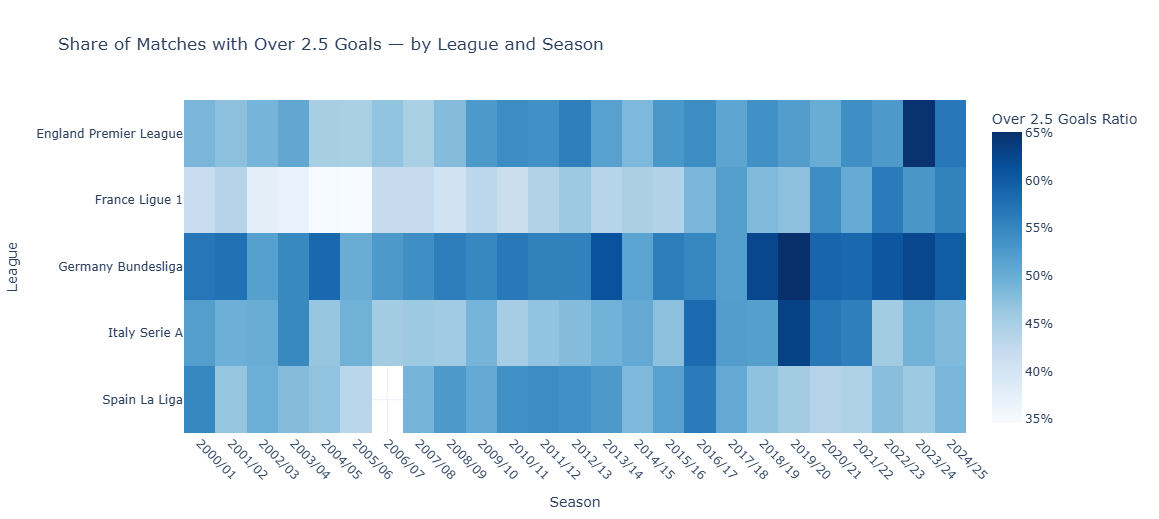

In [52]:
fig_q11 = px.imshow(
    df_q11_pivot,
    title="Share of Matches with Over 2.5 Goals — by League and Season",
    labels=dict(x="Season", y="League", color="Over 2.5 Goals Ratio"),
    color_continuous_scale='Blues',
    aspect='auto'
)

fig_q11.update_layout(
    width=1400,
    height=500
)

fig_q11.update_xaxes(
    tickangle=45
)

fig_q11.update_coloraxes(
    colorbar_tickformat='.0%'
)

fig_q11.show()